# 05 - December 2025 deep dive

Focus on the champion's worst visible month: December 2025. Inspect trade clusters, symbol/side damage, equity drawdown, and price context around entries/exits.

In [1]:
import json
import sys; sys.path.insert(0, ".")
from _lab import *

best = json.loads(BEST_JSON.read_text(encoding="utf-8"))
symbols = list(best["symbols"])
params = dict(best["params"])
tf = best["tf"]
start, end = best["period"]

result = run_strategy_file(BEST_STRATEGY_FILE, symbols, start, end, params=params, tf=tf, return_curves=True)
curves = result["curves"]
trades = curves["trades"].copy()
trades["entry_time"] = pd.to_datetime(trades["entry_time"], utc=True)
trades["exit_time"] = pd.to_datetime(trades["exit_time"], utc=True)
trades["side"] = trades["direction"].str.lower()

dec_start = pd.Timestamp("2025-12-01", tz="UTC")
dec_end = pd.Timestamp("2026-01-01", tz="UTC")
dec = trades[(trades["entry_time"] >= dec_start) & (trades["entry_time"] < dec_end)].copy()
print("December trades:", len(dec))
print("December PnL:", dec["pnl_quote"].sum())
print("December win rate:", (dec["return_pct"] > 0).mean())
dec.head()

December trades: 25
December PnL: -1824.6211283216348
December win rate: 0.32


,entry_time,exit_time,symbol,direction,size,entry_price,exit_price,pnl_quote,return_pct,duration_hours,slice,entry_notional_usd,entry_daily_volume_usd,participation_pct,side
169,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,BTCUSDT,Short,0.067381,86420.724958,91507.957293,-349.375703,-0.059998,36.0,oos,5823.097262,1.214972e+10,0.000048,short
170,2025-12-05 20:00:00+00:00,2025-12-07 20:00:00+00:00,BTCUSDT,Short,0.060874,89265.027426,90356.844947,-72.476999,-0.013338,48.0,oos,5433.906742,8.381467e+09,0.000065,short
171,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,Long,0.058827,93748.202080,90238.331555,-212.428241,-0.038519,36.0,oos,5514.931484,8.072961e+09,0.000068,long
172,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,Short,0.064953,86132.774457,86065.553787,-1.785463,-0.000319,48.0,oos,5594.609219,8.677116e+09,0.000064,short
173,2025-12-18 20:00:00+00:00,2025-12-19 16:00:00+00:00,BTCUSDT,Short,0.064286,85461.552990,87781.713638,-155.279111,-0.028264,20.0,oos,5493.976069,1.023115e+10,0.000054,short


In [2]:
# Add entry context for December.
data = load_pair_data(symbols, start, end, tf=tf)
ctx_rows = []
for sym, df in data.items():
    d = df.copy()
    avg_volume = d["volume"].rolling(params["volume_ma"], min_periods=params["volume_ma"]).mean().shift(1)
    d["vol_ratio"] = d["volume"] / avg_volume
    d["prior_24h_ret"] = d["close"].pct_change(6)
    d["prior_3d_ret"] = d["close"].pct_change(18)
    d["realized_vol_7d"] = d["close"].pct_change().rolling(42).std() * np.sqrt(6 * 365)
    d["bar_range_pct"] = (d["high"] - d["low"]) / d["close"]
    d["symbol"] = sym
    ctx_rows.append(d[["symbol", "open", "high", "low", "close", "volume", "vol_ratio", "prior_24h_ret", "prior_3d_ret", "realized_vol_7d", "bar_range_pct"]])
ctx = pd.concat(ctx_rows).reset_index().rename(columns={"timestamp": "entry_time"})
dec = dec.merge(ctx, on=["entry_time", "symbol"], how="left")
dec[["entry_time", "exit_time", "symbol", "side", "pnl_quote", "return_pct", "duration_hours", "vol_ratio", "prior_24h_ret", "prior_3d_ret", "realized_vol_7d"]]

,entry_time,exit_time,symbol,side,pnl_quote,return_pct,duration_hours,vol_ratio,prior_24h_ret,prior_3d_ret,realized_vol_7d
0,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,BTCUSDT,short,-349.375703,-0.059998,36.0,1.592464,-0.048727,-0.047990,0.496994
1,2025-12-05 20:00:00+00:00,2025-12-07 20:00:00+00:00,BTCUSDT,short,-72.476999,-0.013338,48.0,0.476581,-0.029969,-0.021569,0.533399
2,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,long,-212.428241,-0.038519,36.0,2.942280,0.040920,0.049215,0.396745
3,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,short,-1.785463,-0.000319,48.0,3.506998,-0.028094,-0.044869,0.481622
4,2025-12-18 20:00:00+00:00,2025-12-19 16:00:00+00:00,BTCUSDT,short,-155.279111,-0.028264,20.0,0.916380,-0.008436,-0.010668,0.520383
5,2025-12-26 04:00:00+00:00,2025-12-26 16:00:00+00:00,BTCUSDT,long,-65.568493,-0.012266,12.0,1.128821,0.007290,0.010481,0.276199
6,2025-12-29 04:00:00+00:00,2025-12-29 12:00:00+00:00,BTCUSDT,long,-120.902084,-0.022814,8.0,1.828346,0.021339,0.012922,0.346801
7,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,ETHUSDT,short,-360.767794,-0.061037,36.0,1.239089,-0.055044,-0.053907,0.649721
8,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,long,-189.894584,-0.033407,52.0,0.922767,0.037314,0.030886,0.733748
9,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,long,435.578645,0.080723,48.0,1.455873,0.007047,-0.023570,0.848582


In [3]:
def slice_table(df, by):
    out = df.groupby(by).agg(
        n=("return_pct", "size"),
        pnl=("pnl_quote", "sum"),
        avg_ret=("return_pct", "mean"),
        med_ret=("return_pct", "median"),
        win_rate=("return_pct", lambda s: (s > 0).mean()),
        avg_win=("pnl_quote", lambda s: s[s > 0].mean()),
        avg_loss=("pnl_quote", lambda s: s[s <= 0].mean()),
        avg_duration_h=("duration_hours", "mean"),
    )
    out["payoff"] = out["avg_win"].abs() / out["avg_loss"].abs()
    return out.sort_values("pnl", ascending=False)

display(slice_table(dec, "symbol"))
display(slice_table(dec, ["symbol", "side"]))
display(slice_table(dec, "side"))

,n,pnl,avg_ret,med_ret,win_rate,avg_win,avg_loss,avg_duration_h,payoff
symbol,,,,,,,,,
ETHUSDT,8,-46.529614,-0.001509,-0.015996,0.375,313.849104,-197.615385,38.500000,1.588182
AVAXUSDT,5,-230.212513,-0.007342,0.002498,0.600,218.983596,-443.581650,28.800000,0.493671
SOLUSDT,5,-570.062909,-0.020983,-0.001704,0.400,95.995429,-254.017922,25.600000,0.377908
BTCUSDT,7,-977.816093,-0.025074,-0.022814,0.000,NaN,-139.688013,29.714286,NaN


n         pnl   avg_ret   med_ret  win_rate     avg_win  \
symbol   side                                                             
ETHUSDT  long   3   86.166689  0.005739 -0.030097  0.333333  435.578645   
AVAXUSDT long   2  -49.292899 -0.000437 -0.000437  0.500000  422.461198   
ETHUSDT  short  5 -132.696303 -0.005859 -0.001895  0.400000  252.984333   
AVAXUSDT short  3 -180.919613 -0.011946  0.002498  0.666667  117.244794   
SOLUSDT  long   2 -187.691932 -0.017733 -0.017733  0.500000    3.170837   
         short  3 -382.370977 -0.023150 -0.001704  0.333333  188.820022   
BTCUSDT  long   3 -398.898818 -0.024533 -0.022814  0.000000         NaN   
         short  4 -578.917276 -0.025480 -0.020801  0.000000         NaN   

                  avg_loss  avg_duration_h    payoff  
symbol   side                                         
ETHUSDT  long  -174.705978       37.333333  2.493210  
AVAXUSDT long  -471.754097       32.000000  0.895511  
ETHUSDT  short -212.888323       39.200000  1.188343  
AVAXUSDT short -415.409202       26.666667  0.282239  
SOLUSDT  long  -190.862769        6.000000  0.016613  
         short -285.595499       38.666667  0.661145  
BTCUSDT  long  -132.966273       18.666667       NaN  
         short -144.729319       38.000000       NaN

,n,pnl,avg_ret,med_ret,win_rate,avg_win,avg_loss,avg_duration_h,payoff
side,,,,,,,,,
long,10,-549.716960,-0.009272,-0.026456,0.300000,287.070226,-201.561091,24.400000,1.424234
short,15,-1274.904168,-0.015767,-0.001895,0.333333,185.855655,-220.418245,36.266667,0.843195


In [4]:
# Cluster by entry day: this shows whether losses are one synchronized event or repeated failure.
dec["entry_day"] = dec["entry_time"].dt.floor("D")
daily = slice_table(dec, "entry_day")
daily

,n,pnl,avg_ret,med_ret,win_rate,avg_win,avg_loss,avg_duration_h,payoff
entry_day,,,,,,,,,
2025-12-07 00:00:00+00:00,1,435.578645,0.080723,0.080723,1.000000,435.578645,NaN,48.000000,NaN
2025-12-12 00:00:00+00:00,1,431.870039,0.068784,0.068784,1.000000,431.870039,NaN,120.000000,NaN
2025-12-02 00:00:00+00:00,1,422.461198,0.079581,0.079581,1.000000,422.461198,NaN,28.000000,NaN
2025-12-15 00:00:00+00:00,3,408.326882,0.021654,0.028003,0.666667,205.056173,-1.785463,58.666667,114.847593
2025-12-17 00:00:00+00:00,1,74.098628,0.013614,0.013614,1.000000,74.098628,NaN,20.000000,NaN
2025-12-23 00:00:00+00:00,3,-5.816822,-0.000367,-0.001704,0.333333,13.197265,-9.507044,6.666667,1.388157
2025-12-26 00:00:00+00:00,1,-65.568493,-0.012266,-0.012266,0.000000,NaN,-65.568493,12.000000,NaN
2025-12-05 00:00:00+00:00,1,-72.476999,-0.013338,-0.013338,0.000000,NaN,-72.476999,48.000000,NaN
2025-12-03 00:00:00+00:00,1,-189.894584,-0.033407,-0.033407,0.000000,NaN,-189.894584,52.000000,NaN


[saved] notebooks\volume_weighted_breakout\_out\05_december_2025_equity_drawdown.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/05_december_2025_equity_drawdown.png')

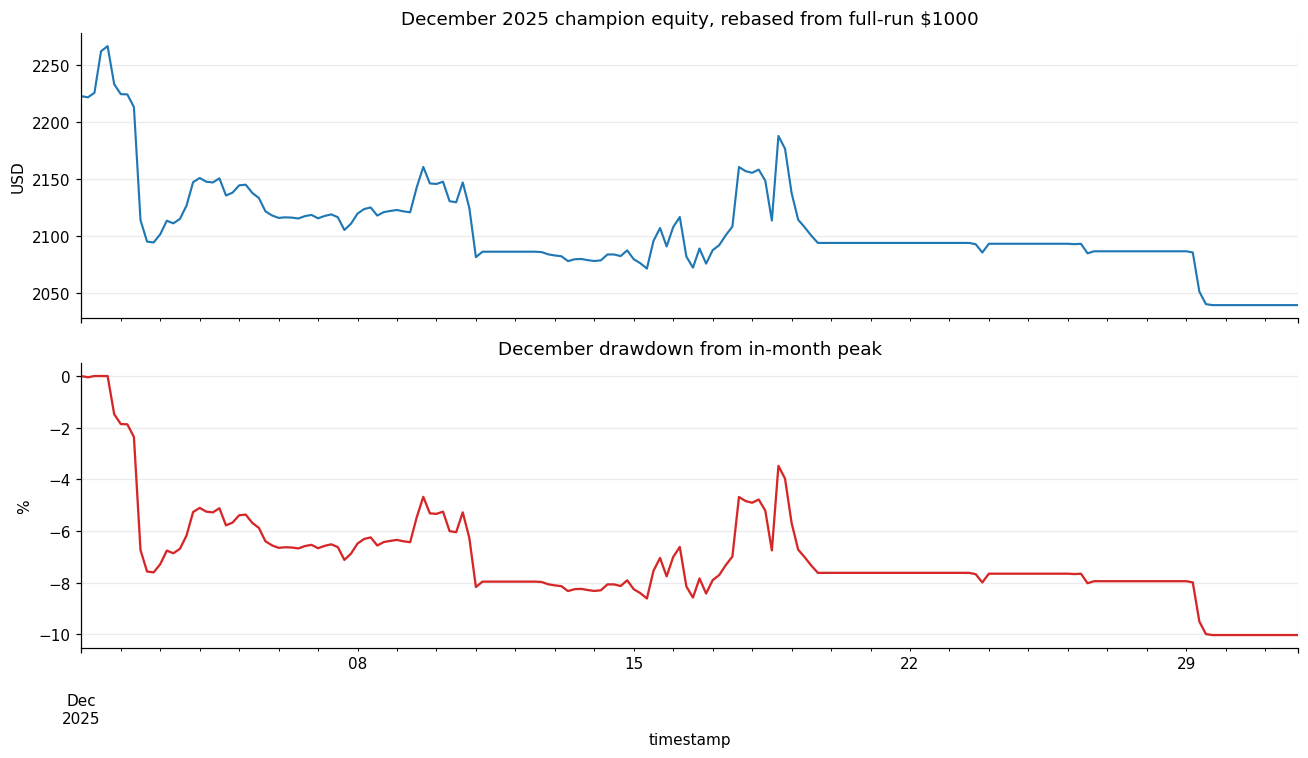

In [5]:
equity = rebase(curves["equity"], 1000.0)
eq_dec = equity[(equity.index >= dec_start) & (equity.index < dec_end)]
dd_dec = drawdown(eq_dec)

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
eq_dec.plot(ax=ax[0], lw=1.4)
ax[0].set_title("December 2025 champion equity, rebased from full-run $1000")
ax[0].set_ylabel("USD")
(dd_dec * 100).plot(ax=ax[1], color="C3")
ax[1].set_title("December drawdown from in-month peak")
ax[1].set_ylabel("%")
show("05_december_2025_equity_drawdown")

[saved] notebooks\volume_weighted_breakout\_out\05_december_2025_daily_trade_pnl.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/05_december_2025_daily_trade_pnl.png')

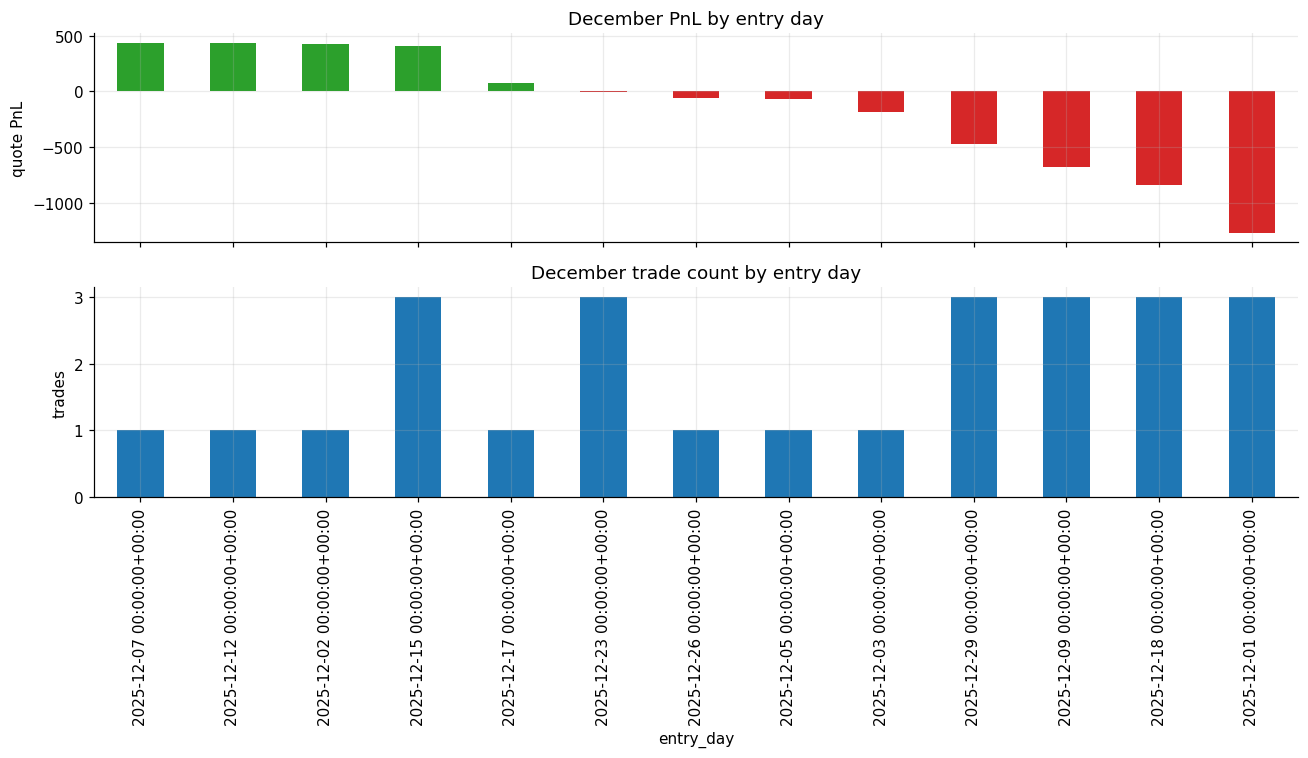

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
daily["pnl"].plot(kind="bar", ax=ax[0], color=np.where(daily["pnl"] >= 0, "C2", "C3"))
ax[0].set_title("December PnL by entry day")
ax[0].set_ylabel("quote PnL")
daily["n"].plot(kind="bar", ax=ax[1], color="C0")
ax[1].set_title("December trade count by entry day")
ax[1].set_ylabel("trades")
show("05_december_2025_daily_trade_pnl")

[saved] notebooks\volume_weighted_breakout\_out\05_december_2025_price_context.png


WindowsPath('C:/Users/digbi/Projects/research-lab/notebooks/volume_weighted_breakout/_out/05_december_2025_price_context.png')

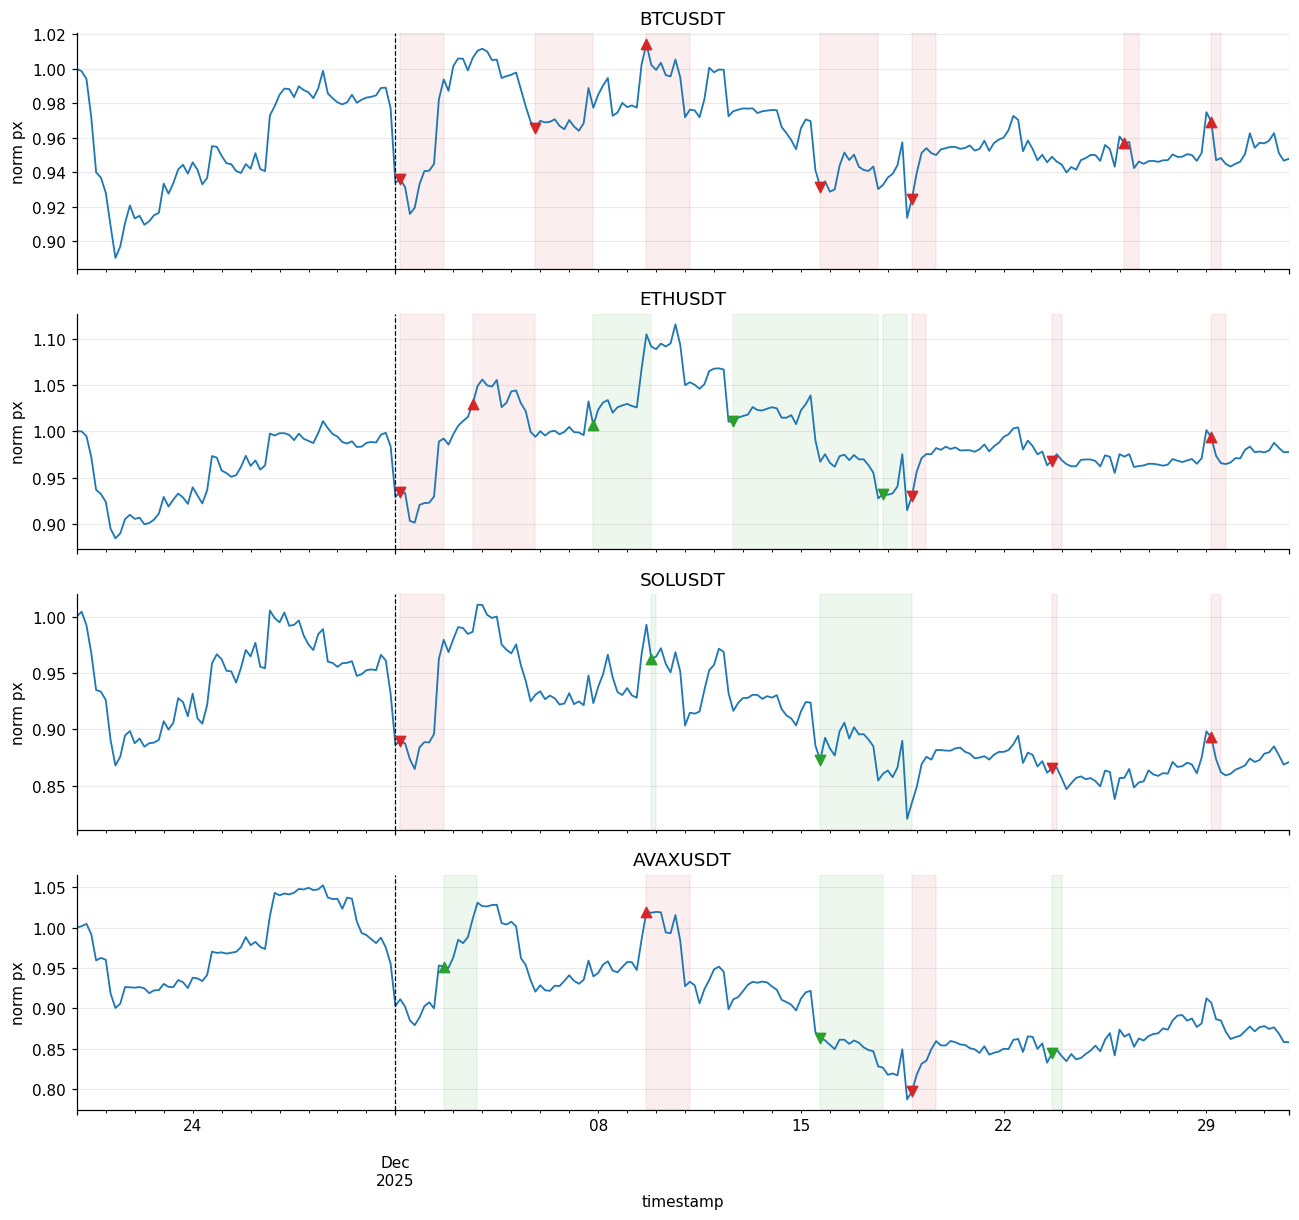

In [7]:
# Price context around the full month, with trade entries/exits.
plot_start = pd.Timestamp("2025-11-20", tz="UTC")
plot_end = pd.Timestamp("2026-01-01", tz="UTC")
fig, ax = plt.subplots(len(symbols), 1, figsize=(12, 2.8 * len(symbols)), sharex=True)
if len(symbols) == 1:
    ax = [ax]
for axis, sym in zip(ax, symbols):
    px = data[sym].loc[plot_start:plot_end, "close"]
    (px / px.iloc[0]).plot(ax=axis, lw=1.2, label=f"{sym} close, normalized")
    sub = dec[dec["symbol"] == sym]
    for _, row in sub.iterrows():
        color = "C2" if row["pnl_quote"] >= 0 else "C3"
        marker = "^" if row["side"] == "long" else "v"
        if row["entry_time"] in px.index:
            axis.scatter(row["entry_time"], px.loc[row["entry_time"]] / px.iloc[0], color=color, marker=marker, s=45, zorder=3)
        axis.axvspan(row["entry_time"], row["exit_time"], color=color, alpha=0.08)
    axis.axvline(dec_start, color="k", lw=0.8, ls="--")
    axis.set_title(sym)
    axis.set_ylabel("norm px")
show("05_december_2025_price_context")

In [8]:
# Worst December trades with context.
cols = ["entry_time", "exit_time", "symbol", "side", "pnl_quote", "return_pct", "duration_hours", "vol_ratio", "prior_24h_ret", "prior_3d_ret", "realized_vol_7d", "bar_range_pct"]
display(dec[cols].sort_values("pnl_quote").head(15))
display(dec[cols].sort_values("pnl_quote", ascending=False).head(15))

,entry_time,exit_time,symbol,side,pnl_quote,return_pct,duration_hours,vol_ratio,prior_24h_ret,prior_3d_ret,realized_vol_7d,bar_range_pct
15,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,SOLUSDT,short,-562.188100,-0.095750,36.0,1.090059,-0.066989,-0.083513,0.791270,0.012569
21,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,AVAXUSDT,long,-471.754097,-0.080455,36.0,2.824444,0.079303,0.099023,0.695301,0.041185
23,2025-12-18 20:00:00+00:00,2025-12-19 16:00:00+00:00,AVAXUSDT,short,-415.409202,-0.075612,20.0,0.845305,-0.035431,-0.073194,0.872229,0.024751
7,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,ETHUSDT,short,-360.767794,-0.061037,36.0,1.239089,-0.055044,-0.053907,0.649721,0.013219
0,2025-12-01 04:00:00+00:00,2025-12-02 16:00:00+00:00,BTCUSDT,short,-349.375703,-0.059998,36.0,1.592464,-0.048727,-0.047990,0.496994,0.011072
12,2025-12-18 20:00:00+00:00,2025-12-19 08:00:00+00:00,ETHUSDT,short,-267.885986,-0.048760,12.0,0.762656,-0.001931,-0.045980,0.823494,0.020959
2,2025-12-09 16:00:00+00:00,2025-12-11 04:00:00+00:00,BTCUSDT,long,-212.428241,-0.038519,36.0,2.942280,0.040920,0.049215,0.396745,0.020245
19,2025-12-29 04:00:00+00:00,2025-12-29 12:00:00+00:00,SOLUSDT,long,-190.862769,-0.036051,8.0,0.842769,0.029642,0.042064,0.521643,0.015489
8,2025-12-03 16:00:00+00:00,2025-12-05 20:00:00+00:00,ETHUSDT,long,-189.894584,-0.033407,52.0,0.922767,0.037314,0.030886,0.733748,0.025192
14,2025-12-29 04:00:00+00:00,2025-12-29 16:00:00+00:00,ETHUSDT,long,-159.517371,-0.030097,12.0,1.869226,0.027449,0.021362,0.439388,0.018324


,entry_time,exit_time,symbol,side,pnl_quote,return_pct,duration_hours,vol_ratio,prior_24h_ret,prior_3d_ret,realized_vol_7d,bar_range_pct
9,2025-12-07 20:00:00+00:00,2025-12-09 20:00:00+00:00,ETHUSDT,long,435.578645,0.080723,48.0,1.455873,0.007047,-0.023570,0.848582,0.044136
10,2025-12-12 16:00:00+00:00,2025-12-17 16:00:00+00:00,ETHUSDT,short,431.870039,0.068784,120.0,1.541048,-0.037932,-0.084801,0.771672,0.018677
20,2025-12-02 16:00:00+00:00,2025-12-03 20:00:00+00:00,AVAXUSDT,long,422.461198,0.079581,28.0,0.984227,0.082097,-0.055459,0.820415,0.014661
22,2025-12-15 16:00:00+00:00,2025-12-17 20:00:00+00:00,AVAXUSDT,short,221.292324,0.037276,52.0,2.520795,-0.044960,-0.052124,0.927055,0.027213
17,2025-12-15 16:00:00+00:00,2025-12-18 20:00:00+00:00,SOLUSDT,short,188.820022,0.028003,76.0,2.326528,-0.040550,-0.047572,0.814906,0.029376
11,2025-12-17 20:00:00+00:00,2025-12-18 16:00:00+00:00,ETHUSDT,short,74.098628,0.013614,20.0,0.537760,-0.043311,-0.074921,0.685451,0.012279
24,2025-12-23 16:00:00+00:00,2025-12-24 00:00:00+00:00,AVAXUSDT,short,13.197265,0.002498,8.0,1.364899,-0.002061,-0.012157,0.796999,0.023375
16,2025-12-09 20:00:00+00:00,2025-12-10 00:00:00+00:00,SOLUSDT,long,3.170837,0.000585,4.0,1.380676,0.034687,0.043146,0.706018,0.040998
3,2025-12-15 16:00:00+00:00,2025-12-17 16:00:00+00:00,BTCUSDT,short,-1.785463,-0.000319,48.0,3.506998,-0.028094,-0.044869,0.481622,0.024468
18,2025-12-23 16:00:00+00:00,2025-12-23 20:00:00+00:00,SOLUSDT,short,-9.002898,-0.001704,4.0,1.498201,-0.005299,-0.016432,0.770966,0.017595


In [9]:
# Compare December entries to non-December OOS entries.
oos = trades[trades["slice"] == "oos"].copy()
oos = oos.merge(ctx, on=["entry_time", "symbol"], how="left")
oos["is_december"] = (oos["entry_time"] >= dec_start) & (oos["entry_time"] < dec_end)
oos.groupby(["is_december", "side"]).agg(
    n=("return_pct", "size"),
    pnl=("pnl_quote", "sum"),
    avg_ret=("return_pct", "mean"),
    med_ret=("return_pct", "median"),
    win_rate=("return_pct", lambda s: (s > 0).mean()),
    vol_ratio=("vol_ratio", "median"),
    prior_24h_ret=("prior_24h_ret", "median"),
    prior_3d_ret=("prior_3d_ret", "median"),
    realized_vol_7d=("realized_vol_7d", "median"),
)

n          pnl   avg_ret   med_ret  win_rate  vol_ratio  \
is_december side                                                              
False       long   48  1054.600126  0.005252  0.000600  0.500000   1.510419   
            short  64  1437.343055  0.002287 -0.002044  0.484375   1.285684   
True        long   10  -549.716960 -0.009272 -0.026456  0.300000   1.418274   
            short  15 -1274.904168 -0.015767 -0.001895  0.333333   1.364899   

                   prior_24h_ret  prior_3d_ret  realized_vol_7d  
is_december side                                                 
False       long        0.037109      0.047595         0.525873  
            short      -0.037561     -0.047266         0.558227  
True        long        0.032164      0.026124         0.608472  
            short      -0.035431     -0.047572         0.770966